In [1]:
import numpy as np
import scipy.signal as sig
import notebooks.models_from_francisco as models 
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import time
# %matplotlib widget

%load_ext autoreload
%autoreload 2 

# Stuart-Landau Model

## Compile numba code

In [12]:
data_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/01_consensus_bin_density_10_percent_50.npy"
connectomes = np.load(data_path)[:5]

In [ ]:
# Runs short simulation just in case to compile the numba function

sim_time = 5 # in seconds
dt = 0.1 # in seconds
W = connectomes[0].astype(float)
W/=np.nanmean(W)
Z = models.simulate_stuart_landau(W = W, sim_time = sim_time, dt = dt)

## Effect of simulation time length in metastability estimation and DFA analysis

In [4]:
W = connectomes[0].astype(float)
W/=np.nanmean(W)
K = 0.03
dt = 1e-2 # in seconds

sim_time_vec = np.arange(1, 15.1, 0.5) * 60 # in seconds
N_trials = 20

sync_vec = np.zeros((len(sim_time_vec), N_trials))
meta_vec = np.zeros((len(sim_time_vec), N_trials))
DFA_vec = np.zeros((len(sim_time_vec), N_trials))
real_time_sim = np.zeros((len(sim_time_vec), N_trials))
real_time_total = np.zeros((len(sim_time_vec), N_trials))

# for i, sim_time in enumerate(tqdm(sim_time_vec)):
for i, sim_time in enumerate(sim_time_vec):
    for j in range(N_trials):

        start = time.time()
        Z = models.simulate_stuart_landau(W = K * W, sim_time = sim_time + 10, dt = dt)
        real_time_sim[i, j] = time.time() - start

        # Removes transient
        Z = Z[:, int(10/dt):]
        signal = np.real(Z)

        # Downsamples signal to sampling rates characteristic of BOLD -> makes further calculations much faster
        dt_ds = 0.5 # Sampling frequency of 2 Hz
        signal_ds = signal[:, ::int(dt_ds/dt)]

        # Filters signal in band of interest
        b, a = sig.butter(N = 2, Wn = [0.01, 0.1], btype = 'bandpass', fs = 1/dt_ds)
        signal_filt = sig.filtfilt(b, a, signal_ds, axis = -1)
        # Removes some signal from beginning and end to avoid edge effects from filter
        signal_filt = signal_filt[:, int(5/dt):-int(5/dt)]

        # Computes KOP, sync and meta
        KOP_global, _ = models.compute_KOP(signal = signal_ds, fs = 1/dt)

        sync_vec[i, j] = np.nanmean(KOP_global)
        meta_vec[i, j] = np.nanstd(KOP_global)

        # Detrended fluctuation analysis
        ws = np.logspace(np.log10(15), np.log10(45), 5)
        DFA, _ = models.DFA_analysis(signal_ds, window_sizes = ws, fs = 1/dt_ds)

        DFA_vec[i, j] = np.nanmean(DFA)

        real_time_total[i, j] = time.time() - start
    
    print(f"Finished sim time {sim_time/60:.1f} min")

# np.save('Data/SL_model/sim_time/sync_vs_sim_time.npy', sync_vec)
# np.save('Data/SL_model/sim_time/meta_vs_sim_time.npy', meta_vec)
# np.save('Data/SL_model/sim_time/DFA_vec.npy', DFA_vec)
# np.save('Data/SL_model/sim_time/real_time_sim.npy', real_time_sim)
# np.save('Data/SL_model/sim_time/real_time_total.npy', real_time_total)

# took 9 min 56 sec

Finished sim time 1.0 min
Finished sim time 1.5 min
Finished sim time 2.0 min
Finished sim time 2.5 min
Finished sim time 3.0 min
Finished sim time 3.5 min
Finished sim time 4.0 min
Finished sim time 4.5 min
Finished sim time 5.0 min
Finished sim time 5.5 min
Finished sim time 6.0 min
Finished sim time 6.5 min
Finished sim time 7.0 min
Finished sim time 7.5 min
Finished sim time 8.0 min
Finished sim time 8.5 min
Finished sim time 9.0 min
Finished sim time 9.5 min
Finished sim time 10.0 min
Finished sim time 10.5 min
Finished sim time 11.0 min
Finished sim time 11.5 min
Finished sim time 12.0 min
Finished sim time 12.5 min
Finished sim time 13.0 min
Finished sim time 13.5 min
Finished sim time 14.0 min
Finished sim time 14.5 min
Finished sim time 15.0 min


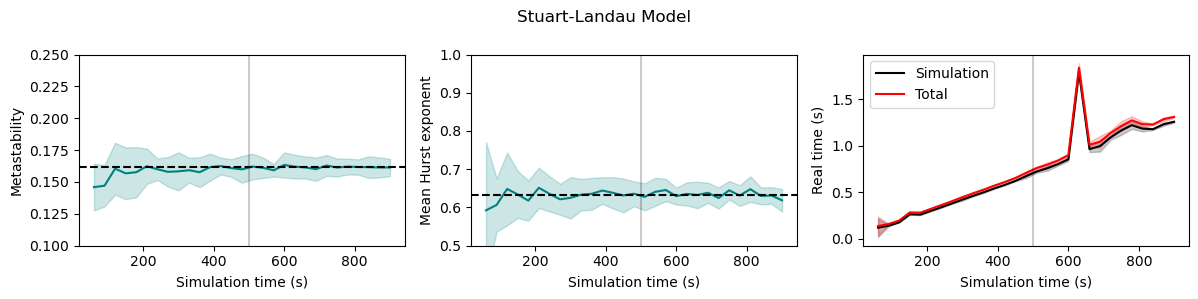

In [5]:
sim_time_vec = np.arange(1, 15.1, 0.5) * 60 # in seconds

# meta_vec = np.load('Data/SL_model/sim_time/meta_vs_sim_time.npy')
# DFA_vec = np.load('Data/SL_model/sim_time/DFA_vec.npy')
# real_time_sim = np.load('Data/SL_model/sim_time/real_time_sim.npy')
# real_time_total = np.load('Data/SL_model/sim_time/real_time_total.npy')

plt.figure(figsize = (12, 3))

plt.suptitle('Stuart-Landau Model')

plt.subplot(1, 3, 1)
plt.plot(sim_time_vec, np.nanmean(meta_vec, axis = -1), color = 'teal')
plt.fill_between(sim_time_vec, 
                 np.nanmean(meta_vec, axis = -1) - np.nanstd(meta_vec, axis = -1), 
                 np.nanmean(meta_vec, axis = -1) + np.nanstd(meta_vec, axis = -1), 
                 color = 'teal', alpha = 0.2)

plt.axhline(y = np.nanmean(meta_vec[-10:, :]), color = 'k', linestyle = '--')
plt.axvline(x = 500, color = 'k', alpha = 0.2)

plt.ylabel('Metastability')
plt.xlabel('Simulation time (s)')
plt.ylim([0.1, 0.25])


plt.subplot(1, 3, 2)
plt.plot(sim_time_vec, np.nanmean(DFA_vec, axis = -1), color = 'teal')
plt.fill_between(sim_time_vec, 
                 np.nanmean(DFA_vec, axis = -1) - np.nanstd(DFA_vec, axis = -1), 
                 np.nanmean(DFA_vec, axis = -1) + np.nanstd(DFA_vec, axis = -1), 
                 color = 'teal', alpha = 0.2)

plt.axhline(y = np.nanmean(DFA_vec[-10:, :]), color = 'k', linestyle = '--')
plt.axvline(x = 500, color = 'k', alpha = 0.2)

plt.ylim([0.5, 1])
plt.ylabel('Mean Hurst exponent')
plt.xlabel('Simulation time (s)')

plt.subplot(1, 3, 3)
plt.plot(sim_time_vec, np.nanmean(real_time_sim, axis = -1), color = 'k', label = 'Simulation')
plt.fill_between(sim_time_vec, 
                 np.nanmean(real_time_sim, axis = -1) - np.nanstd(real_time_sim, axis = -1), 
                 np.nanmean(real_time_sim, axis = -1) + np.nanstd(real_time_sim, axis = -1), 
                 color = 'k', alpha = 0.2)

plt.plot(sim_time_vec, np.nanmean(real_time_total, axis = -1), 'r', label = 'Total')
plt.fill_between(sim_time_vec, 
                 np.nanmean(real_time_total, axis = -1) - np.nanstd(real_time_total, axis = -1), 
                 np.nanmean(real_time_total, axis = -1) + np.nanstd(real_time_total, axis = -1), 
                 color = 'r', alpha = 0.2)
plt.axvline(x = 500, color = 'k', alpha = 0.2)

plt.legend()
plt.ylabel('Real time (s)')
plt.xlabel('Simulation time (s)')

plt.tight_layout()
plt.show()

## Varying Global Coupling (K)

In [6]:
K_vec = np.logspace(-4, 0, 101)

meta_global_vec = np.zeros((len(K_vec)))
meta_local_vec = np.zeros((len(K_vec), W.shape[0]))
DFA_vec = np.zeros((len(K_vec), W.shape[0]))

# for i, K in enumerate(tqdm(K_vec)):
for i, K in enumerate(K_vec):
    meta_global, meta_local, DFA = models.evaluate_network(W = W, K = K, sim_time = 500)

    meta_global_vec[i] = meta_global
    meta_local_vec[i, :] = meta_local
    DFA_vec[i, :] = DFA
    print(f"Finished K {K:.4f}")

Finished K 0.0001
Finished K 0.0001
Finished K 0.0001
Finished K 0.0001
Finished K 0.0001
Finished K 0.0002
Finished K 0.0002
Finished K 0.0002
Finished K 0.0002
Finished K 0.0002
Finished K 0.0003
Finished K 0.0003
Finished K 0.0003
Finished K 0.0003
Finished K 0.0004
Finished K 0.0004
Finished K 0.0004
Finished K 0.0005
Finished K 0.0005
Finished K 0.0006
Finished K 0.0006
Finished K 0.0007
Finished K 0.0008
Finished K 0.0008
Finished K 0.0009
Finished K 0.0010
Finished K 0.0011
Finished K 0.0012
Finished K 0.0013
Finished K 0.0014
Finished K 0.0016
Finished K 0.0017
Finished K 0.0019
Finished K 0.0021
Finished K 0.0023
Finished K 0.0025
Finished K 0.0028
Finished K 0.0030
Finished K 0.0033
Finished K 0.0036
Finished K 0.0040
Finished K 0.0044
Finished K 0.0048
Finished K 0.0052
Finished K 0.0058
Finished K 0.0063
Finished K 0.0069
Finished K 0.0076
Finished K 0.0083
Finished K 0.0091
Finished K 0.0100
Finished K 0.0110
Finished K 0.0120
Finished K 0.0132
Finished K 0.0145
Finished K

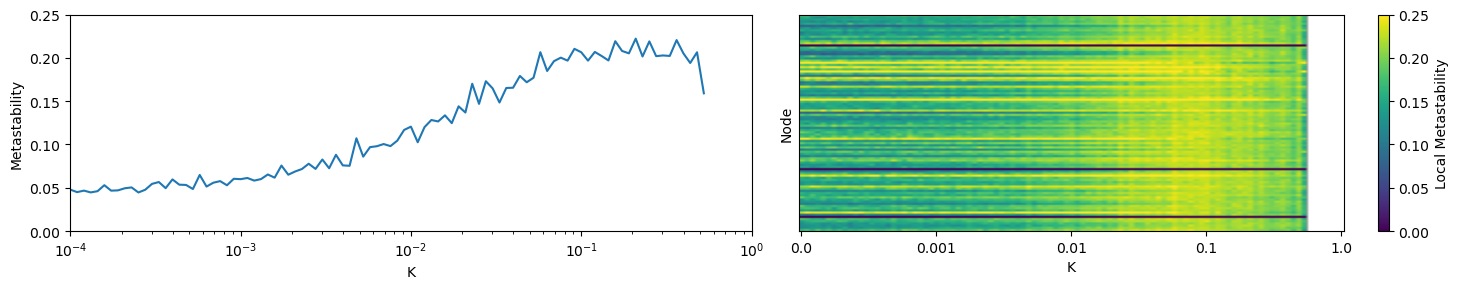

In [7]:
plt.figure(figsize = (15, 3))

# plt.subplot(1, 4, 1)
plt.subplot(1, 2, 1)
plt.plot(K_vec, meta_global_vec)
plt.ylim([0, 0.25])
plt.xlim([K_vec[0], K_vec[-1]])
plt.xscale('log')
plt.ylabel('Metastability')
plt.xlabel('K')

# plt.subplot(1, 4, 2)
plt.subplot(1, 2, 2)
plt.imshow(meta_local_vec.T, aspect = 'auto')
plt.clim([0, 0.25])
c = plt.colorbar()
c.set_label('Local Metastability')
plt.yticks([])
plt.ylabel('Node')
plt.xticks(np.arange(0, len(K_vec), 25), K_vec[::25].round(3))
plt.xlabel('K')



# plt.subplot(1, 4, 3)
# plt.plot(K_vec, np.nanmean(DFA_vec, axis = -1))
# plt.ylim([0.25, 1.0])
# plt.xlim([K_vec[0], K_vec[-1]])
# plt.xscale('log')
# plt.ylabel('Mean Hurst Exponent')
# plt.xlabel('K')

# plt.subplot(1, 4, 4)
# plt.imshow(DFA_vec.T, aspect = 'auto')
# plt.clim([0.5, 1.0])
# c = plt.colorbar()
# c.set_label('Hurst Exponent')
# plt.yticks([])
# plt.ylabel('Node')
# plt.xticks(np.arange(0, len(K_vec), 25), K_vec[::25].round(3))
# plt.xlabel('K')

plt.tight_layout()
plt.show()

In [8]:
K_vec = np.logspace(-1, 0, 20)

meta_global_vec = np.zeros((len(K_vec)))
meta_local_vec = np.zeros((len(K_vec), W.shape[0]))
DFA_vec = np.zeros((len(K_vec), W.shape[0]))

# for i, K in enumerate(tqdm(K_vec)):
for i, K in enumerate(K_vec):
    meta_global, meta_local, DFA = models.evaluate_network(W = W, K = K, sim_time = 500)

    meta_global_vec[i] = meta_global
    meta_local_vec[i, :] = meta_local
    DFA_vec[i, :] = DFA
    print(f"Finished K {K:.4f}")

Finished K 0.1000
Finished K 0.1129
Finished K 0.1274
Finished K 0.1438
Finished K 0.1624
Finished K 0.1833
Finished K 0.2069
Finished K 0.2336
Finished K 0.2637
Finished K 0.2976
Finished K 0.3360
Finished K 0.3793
Finished K 0.4281
Finished K 0.4833
Finished K 0.5456
Finished K 0.6158
Finished K 0.6952
Finished K 0.7848
Finished K 0.8859
Finished K 1.0000


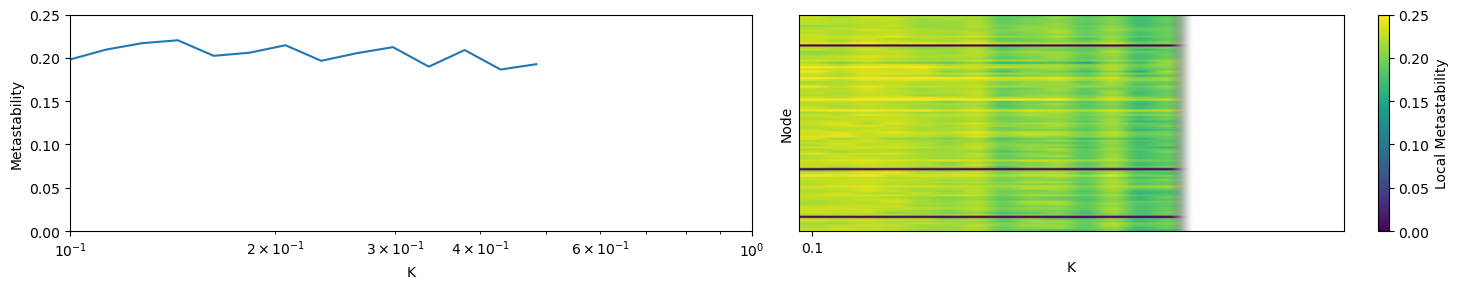

In [9]:
plt.figure(figsize = (15, 3))

# plt.subplot(1, 4, 1)
plt.subplot(1, 2, 1)
plt.plot(K_vec, meta_global_vec)
plt.ylim([0, 0.25])
plt.xlim([K_vec[0], K_vec[-1]])
plt.xscale('log')
plt.ylabel('Metastability')
plt.xlabel('K')

# plt.subplot(1, 4, 2)
plt.subplot(1, 2, 2)
plt.imshow(meta_local_vec.T, aspect = 'auto')
plt.clim([0, 0.25])
c = plt.colorbar()
c.set_label('Local Metastability')
plt.yticks([])
plt.ylabel('Node')
plt.xticks(np.arange(0, len(K_vec), 25), K_vec[::25].round(3))
plt.xlabel('K')



# plt.subplot(1, 4, 3)
# plt.plot(K_vec, np.nanmean(DFA_vec, axis = -1))
# plt.ylim([0.25, 1.0])
# plt.xlim([K_vec[0], K_vec[-1]])
# plt.xscale('log')
# plt.ylabel('Mean Hurst Exponent')
# plt.xlabel('K')

# plt.subplot(1, 4, 4)
# plt.imshow(DFA_vec.T, aspect = 'auto')
# plt.clim([0.5, 1.0])
# c = plt.colorbar()
# c.set_label('Hurst Exponent')
# plt.yticks([])
# plt.ylabel('Node')
# plt.xticks(np.arange(0, len(K_vec), 25), K_vec[::25].round(3))
# plt.xlabel('K')

plt.tight_layout()
plt.show()

# Tests appropriate window for DFA analysis

In [10]:
dt_ds = 0.5
surrogate = np.random.randn(250, 1000) # 250 Random signals -> hurst exponent should be ~0.5

# Filters signal in band of interest
b, a = sig.butter(N = 2, Wn = [0.01, 0.1], btype = 'bandpass', fs = 1/dt_ds)
surrogate_filt = sig.filtfilt(b, a, surrogate, axis = -1)

# Removes some signal from beginning and end to avoid edge effects from filter
surrogate_filt = surrogate_filt[:, int(5/dt_ds):-int(5/dt_ds)]

# Detrended fluctuation analysis
ws = np.logspace(np.log10(10), np.log10(200), 21) # in seconds
DFA, nFt = models.DFA_analysis(surrogate_filt, window_sizes = ws, fs = 1/dt_ds)

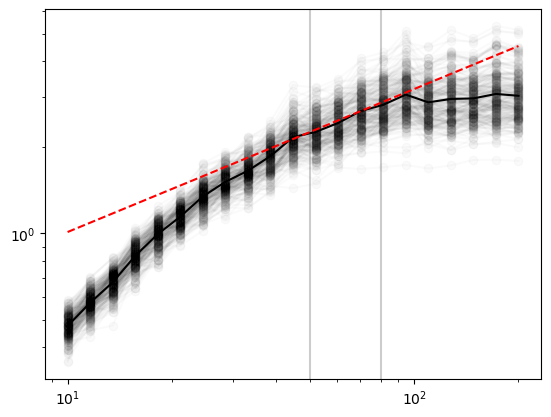

In [11]:
plt.figure()
plt.plot(ws, nFt.T, 'o-', color = 'k', alpha = 0.02)
plt.plot(ws, np.nanmean(nFt, axis = 0), '-', color = 'k')
plt.plot(ws, 0.32*ws**0.5, 'r--')
plt.axvline(x = 50, color = 'k', alpha = 0.2)
plt.axvline(x = 80, color = 'k', alpha = 0.2)
plt.xscale('log')
plt.yscale('log')
plt.show()